# Conversational agent with Nova Sonic and Eleven Labs voices

In this example I will demonstrate how to create a conversational agent that can leverage the deep customization achievable with Eleven Labs voices while keeping a smooth interactive experience with the speaker.

A typical approach to create conversational bots is to use a speech-to-text engine (STT), an LLM to generated the output text and a text-to-speech (TTS) engine to generate the audio output. While this pipeline works fine it can introduce noticeable latency when the LLM is replaced by a more complex agent that might use tools and several loops before returning the control to the user. 

<div style="display: flex; justify-content: center;">
<div style="max-width: 500px">

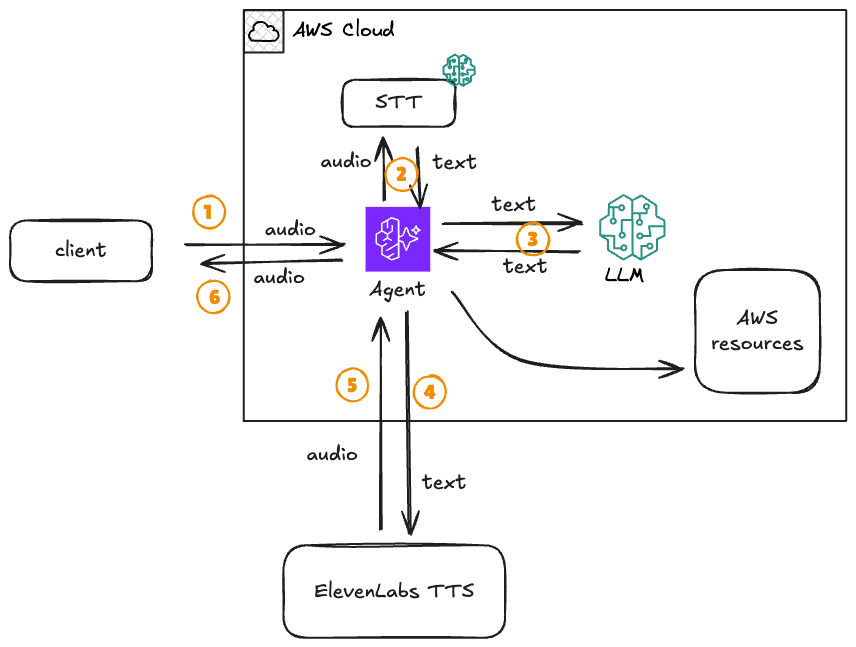

</div>
</div>

Speech-to-speech LLMs like Nova Sonic have been designed to optimally handle such use cases, and run tools in parallel with the generation of the output so that the conversation remains natural and fluid.

One draw back of this approach is the limited selection of voice that such model support, which is far from the rich catalog and customization options offered by niche players like ElevenLabs.

In this example we will see how to combine the best of both worlds, by using Nova Sonic as the conversational agent and Eleven Labs as the TTS engine.

The intuition is to use Nova Sonic to interpret the user input and use the textual output to generate the audio. Nova Sonic generates both the text and the corresponding audio, and we will simply throw away the audio, while still benefitting from Nova Sonic agentic capabilities, tool execution and user activity detection and interrupts. 

<div style="display: flex; justify-content: center;">
<div style="max-width: 500px">

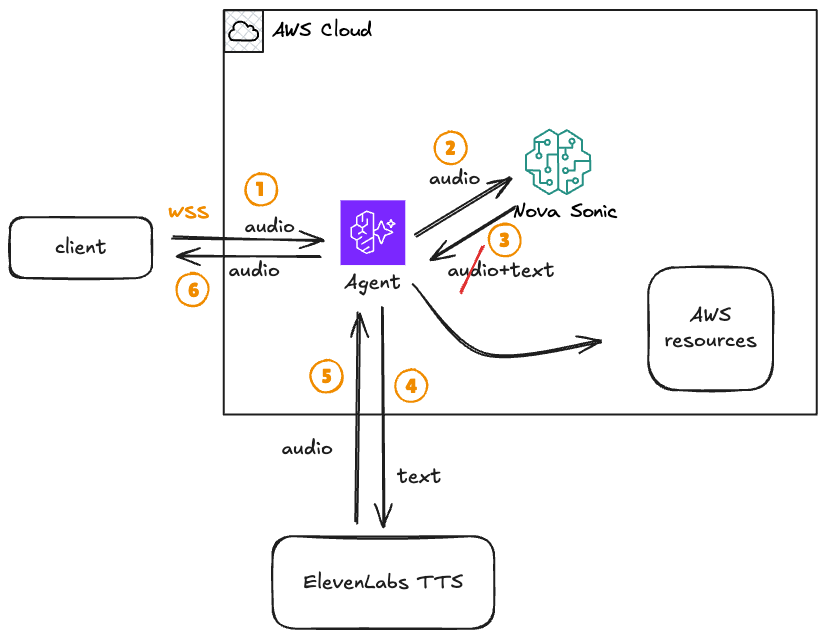

</div>
</div>



## Prerequisites

<div style="background-color: yellow;">

**Note**: this example cannot be run on a cloud Notebook

</div>

Create an account on ElevenLabs. Select Developer on the left menu navigation and then create an API Key. Allow at minimum permissions to do text to speech. Note down the API key.

Copy the `.env.template` file to `.env` and update the ElevenLabs API key. 

To test this example locally we also need to get credentials with permissions to invoke the model from the container. For simplicity create an IAM user to be used only programmatically with a `AmazonBedrockLimitedAccess` policy attached. Note down the Access Key Id and Secret Access Key and update the `.env` file. You can find more information on the different methods to obtain credentials in the [documentation](https://docs.aws.amazon.com/cli/v1/userguide/cli-chap-authentication.html). 

### The agent code

The code of the agent is in `server.py`, which also uses `elevenlabs_io.py` to implement the necessary integrations between the Strands BidiAgent and ElevenLabs. 

Strands `BidiAgent` provides implementations for Amazon Nova Sonic. We are going to use this implementation and we intercept the input and output streams thanks to the ElevenLabsIO class we wrote.

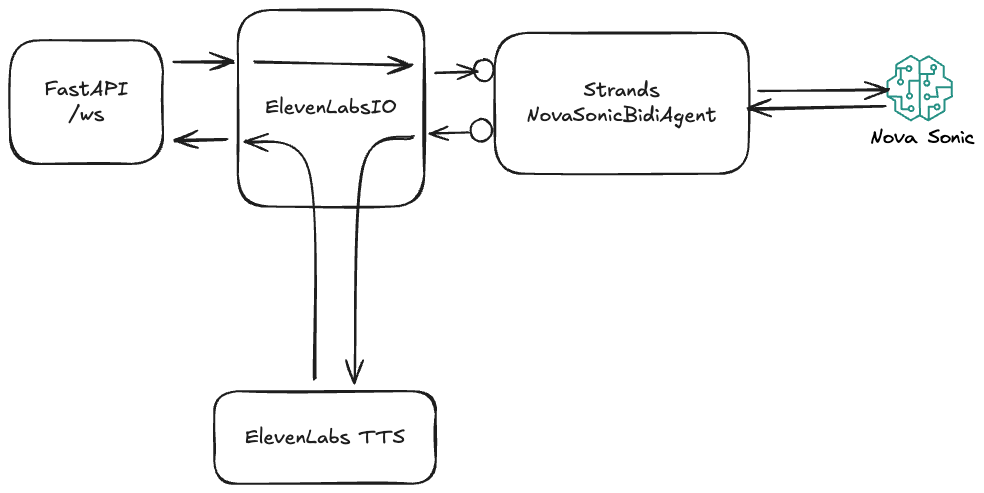

The audio data received via websockets is sent as is to the BidiAgent as we leverage NovaSonic for the generation of the transcript. The Nova Sonic answer relayed by the BidiAgent is intercepted by the ElevenLabsIO implementation. If the event is a text transcript generated by the model (role = assistant) we send it to ElevenLabs API to generate the audio. The resulting audio is then converted to the format expected by the BidiAgent protocol, ie base64 encoded and put into a JSON message like the following:

```json
 {
    "type": "bidi_audio_stream",
    "audio": "audio_b64",
    "format": "pcm",
    "sample_rate": 16000,
    "channels": 1,
}
```
 
Audio events are ignored while all other events are just relayed as-is.


### Build the container

We are going to use a container to test the agent. This allows us to have a reproducible environment even locally and the container can be used as-is to be deployed in AgentCore Runtime. 

Build the container with the following command:

```bash
docker build -t nova-elevenlabs-agent .
```

### Run the container

Run the container with the following command:

```bash
docker run --env-file .env -p 8080:8080 nova-elevenlabs-agent
```

### Test the agent

You can test the agent using the provided client application.

Run the client application with the following command:

```bash 
cd client
npm i
npm run dev
```

Open your browser at `http://localhost:5173` and enter `ws://localhost:8080/ws` as the WebSocket URL, then select **Start Connection**. Allow the browser to access you microphone and start talking to the agent.

You should hear the agent answering you with the ElevenLabs voice you selected in the `.env` file.


## Deploy to AgentCore Runtime

To deploy the agent to AgentCore Runtime you need to push the container to a container registry accessible from your AgentCore Runtime environment, for example Amazon ECR.

Run

```bash
uv venv
```

to create the virtual environment needed to run the following cells.

In [ ]:
import dotenv
import os
dotenv.load_dotenv('.env')

In [ ]:
from bedrock_agentcore_starter_toolkit import Runtime

runtime = Runtime()

We configure the runtime with IAM authentication in order to be able to connect from the client via a pre-signed url.

In [ ]:
config = runtime.configure(
    entrypoint="server.py",
    requirements_file="requirements.txt",
    memory_mode="NO_MEMORY",
    non_interactive=True,
    deployment_type="container",
    protocol="HTTP",
    auto_create_execution_role=True,
    region='us-east-1',
)

This command generates the AgentCore configuration but also overwrites the existing Dockerfile. Let's copy back the correct one:


In [ ]:
!cp Dockerfile.original Dockerfile

Next, we deploy the agent to AgentCore.

In [ ]:
res = runtime.launch(local_build=True, auto_update_on_conflict=True, env_vars={
    "ELEVENLABS_API_KEY": os.environ["ELEVENLABS_API_KEY"],
    "ELEVENLABS_VOICE_ID": os.environ["ELEVENLABS_VOICE_ID"]
})

## Obtain the presigned url

In [ ]:
from bedrock_agentcore.runtime.agent_core_runtime_client import AgentCoreRuntimeClient

client = AgentCoreRuntimeClient(region='us-east-1')

url = client.generate_presigned_url(runtime_arn=res.agent_arn)
print(url)

Copy the presigned url and paste it in the websocket field of the web client. Select Start Connections and after few seconds you can start talking.


## Congratulations!

Through this sample you learned how to implement a conversational agent using Strands `BidiAgent`, Nova Sonic and ElevenLabs voices. You leverage BidiAgents using the BidiNovaSonicModel for a low latency conversational agentic behaviour and you integrated ElevenLabs as speech rendering engine for the rich and customizable experience. Finally, you deployed the solution to Bedrock AgentCore Runtime to benefit from an optimal agent hosting solution that provides scalable and secure bidirectional websockets support.

### Improvements

The current solution is just a basic implementation for demonstration purposes and can be improved in several ways. Among others:
- introduce a lazy audio rendering queue so that audio is not unnecessarily rendered in case the user interrupts the conversation
- interrupt the audio play when the user start to speak and an interrupt signal is generated
